In [1]:
import pandas as pd
import numpy as np

from statsmodels.stats.inter_rater import fleiss_kappa
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

import pandas as pd
import seaborn.objects as so
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
llama_data = pd.read_csv("./web_app/data/llama_data.csv")
gemma_data = pd.read_csv("./web_app/data/gemma_data.csv")
responses = pd.read_csv("persona_eval_results - results.csv")[24:].reset_index(drop=True)

In [3]:
len(responses['client_id'].unique())

13

In [4]:
def get_pos_neg_label(df):

    df["src_a_n"] = df["response_a_source"].astype(str).str.strip().str.lower()
    df["src_b_n"] = df["response_b_source"].astype(str).str.strip().str.lower()
    
    print("label_a unique:", df["label_a"].dropna().unique())
    print("label_b unique:", df["label_b"].dropna().unique())
    print("src_a unique:", df["src_a_n"].dropna().unique())
    print("src_b unique:", df["src_b_n"].dropna().unique())
    
    df["item_id"] = df["dataset_key"].astype(str) + "_" + df["row_index"].astype(str)

    
    def pick_label_for_positive(row):
        if row["src_a_n"] == "positive":
            return row["label_a"]
        if row["src_b_n"] == "positive":
            return row["label_b"]
        return np.nan  # if neither side marked positive (data issue)

    def pick_label_for_negative(row):
        if row["src_a_n"] == "negative":
            return row["label_a"]
        if row["src_b_n"] == "negative":
            return row["label_b"]
        return np.nan


    df["label_for_positive"] = df.apply(pick_label_for_positive, axis=1)
    df["label_for_negative"] = df.apply(pick_label_for_negative, axis=1)


    return df

In [5]:
responses_model_llama = responses[responses['dataset_label'] == "Model 1"]
llama_data_with_index = llama_data.copy()
llama_data_with_index['row_index'] = llama_data_with_index.index

# Now merge using that index
merged_llama = pd.merge(
    responses_model_llama,
    llama_data_with_index,
    left_on=['row_index', 'prompt'],
    right_on=['row_index', 'prompt'],
    how='left'
)
merged_llama = get_pos_neg_label(merged_llama)

label_a unique: ['Assistant persona' 'LLM persona' 'Not coherent']
label_b unique: ['LLM persona' 'Assistant persona' 'Not coherent']
src_a unique: ['positive' 'negative']
src_b unique: ['negative' 'positive']


In [6]:
responses_model_gemma = responses[responses['dataset_label'] == "Model 2"]
gemma_data_with_index = gemma_data.copy()
gemma_data_with_index['row_index'] = gemma_data_with_index.index

# Now merge using that index
merged_gemma = pd.merge(
    responses_model_gemma,
    gemma_data_with_index,
    left_on=['row_index', 'prompt'],
    right_on=['row_index', 'prompt'],
    how='left'
)
merged_gemma = get_pos_neg_label(merged_gemma)

label_a unique: ['Assistant persona' 'LLM persona' 'Not coherent']
label_b unique: ['LLM persona' 'Assistant persona']
src_a unique: ['positive' 'negative']
src_b unique: ['negative' 'positive']


## Get interrater agreement

In [9]:
def get_interrater_agreement_per_polarrity(mat):
    mat_complete = mat.dropna(axis=0)
    print("Complete items:", mat_complete.shape[0], "out of", mat.shape[0])
    
    # categories = ["assistant", "llm", "not coherent"]
    categories = ["Assistant persona", "LLM persona", "Not coherent"]

    counts = pd.DataFrame(index=mat_complete.index, columns=categories, data=0)

    for cat in categories:
        counts[cat] = (mat_complete == cat).sum(axis=1)

    counts = counts.astype(int)

    n_raters = mat_complete.shape[1]
    bad = counts.sum(axis=1) != n_raters
    print("Any rows with wrong total?", bad.any())
    if bad.any():
        print(counts[bad].head())


    per_item_agreement = counts.max(axis=1) / counts.sum(axis=1)
    overall_percent_agreement = per_item_agreement.mean()

    print("Mean percent agreement:", round(overall_percent_agreement, 2))
    print("Per-item agreement summary:\n", per_item_agreement.describe())


def get_interrater_agreement(df):
    print("Positive polarity")
    mat = df.pivot_table(
        index="item_id",
        columns="client_id",
        values="label_for_positive",
        aggfunc="first"   # should be exactly one per (item, client)
    )

    print("Shape (items x raters):", mat.shape)
    # print("Missing ratings per item:\n", mat.isna().sum(axis=1).value_counts().sort_index())
    get_interrater_agreement_per_polarrity(mat)
    
    
    print("\n\nNegative polarity")
    mat = df.pivot_table(
        index="item_id",
        columns="client_id",
        values="label_for_negative",
        aggfunc="first"   # should be exactly one per (item, client)
    )

    print("Shape (items x raters):", mat.shape)
    # print("Missing ratings per item:\n", mat.isna().sum(axis=1).value_counts().sort_index())
    get_interrater_agreement_per_polarrity(mat)
    
    


In [10]:
get_interrater_agreement(merged_llama)

Positive polarity
Shape (items x raters): (12, 13)
Complete items: 12 out of 12
Any rows with wrong total? False
Mean percent agreement: 0.98
Per-item agreement summary:
 count    12.000000
mean      0.980769
std       0.034790
min       0.923077
25%       0.980769
50%       1.000000
75%       1.000000
max       1.000000
dtype: float64


Negative polarity
Shape (items x raters): (12, 13)
Complete items: 12 out of 12
Any rows with wrong total? False
Mean percent agreement: 0.97
Per-item agreement summary:
 count    12.000000
mean      0.967949
std       0.051428
min       0.846154
25%       0.923077
50%       1.000000
75%       1.000000
max       1.000000
dtype: float64


In [11]:
get_interrater_agreement(merged_gemma)

Positive polarity
Shape (items x raters): (12, 13)
Complete items: 12 out of 12
Any rows with wrong total? False
Mean percent agreement: 0.92
Per-item agreement summary:
 count    12.000000
mean      0.923077
std       0.092773
min       0.769231
25%       0.846154
50%       0.961538
75%       1.000000
max       1.000000
dtype: float64


Negative polarity
Shape (items x raters): (12, 13)
Complete items: 12 out of 12
Any rows with wrong total? False
Mean percent agreement: 0.84
Per-item agreement summary:
 count    12.000000
mean      0.839744
std       0.216228
min       0.461538
25%       0.653846
50%       0.961538
75%       1.000000
max       1.000000
dtype: float64


## Plot results

### Majority voting

In [12]:
import pandas as pd
import numpy as np

def majority_vote(series: pd.Series):
    """Return modal label; break ties deterministically."""
    vc = series.dropna().value_counts()
    if vc.empty:
        return np.nan
    top = vc[vc == vc.max()].index.tolist()
    return sorted(top)[0]

def build_majority_counts(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    # Majority vote per item for positive steering
    pos = (
        df.groupby("item_id")["label_for_positive"]
        .apply(majority_vote)
        .reset_index(name="label")
    )
    pos["polarity"] = "Positive"

    # Majority vote per item for negative steering
    neg = (
        df.groupby("item_id")["label_for_negative"]
        .apply(majority_vote)
        .reset_index(name="label")
    )
    neg["polarity"] = "Negative"

    maj = pd.concat([pos, neg], ignore_index=True)

    # Count labels by polarity (this matches your plotting code exactly)
    counts = (
        maj.dropna(subset=["label"])
           .groupby(["polarity", "label"], as_index=False)
           .size()
           .rename(columns={"size": "count"})
    )

    counts["polarity"] = pd.Categorical(
        counts["polarity"],
        categories=["Negative", "Positive"],
        ordered=True
    )
    counts["model"] = model_name
    return counts

# Build majority-vote tables
llama_counts = build_majority_counts(merged_llama, "LLaMA").sort_values('label')
gemma_counts = build_majority_counts(merged_gemma, "Gemma").sort_values('label')

# Sanity check
print(llama_counts)
print(gemma_counts)


   polarity              label  count  model
1  Positive  Assistant persona     12  LLaMA
0  Negative        LLM persona     12  LLaMA
   polarity              label  count  model
0  Negative  Assistant persona      1  Gemma
2  Positive  Assistant persona     11  Gemma
1  Negative        LLM persona     11  Gemma
3  Positive        LLM persona      1  Gemma


In [13]:
llama_counts

,polarity,label,count,model
1,Positive,Assistant persona,12,LLaMA
0,Negative,LLM persona,12,LLaMA


In [14]:
all_labels = pd.concat([llama_counts['label'], gemma_counts['label']]).unique()
colorblind_palette = sns.color_palette("colorblind", n_colors=len(all_labels))
# color_mapping = dict(zip(all_labels, colorblind_palette))

color_mapping = {
    "Not coherent": "#0072B2",      # blue
    "Assistant persona": "#009E73",      # green
    "LLM persona": "#E69F00",       # orange
}


# Define the legend order
legend_order = ['User persona', 'LLM persona', 'Not coherent']

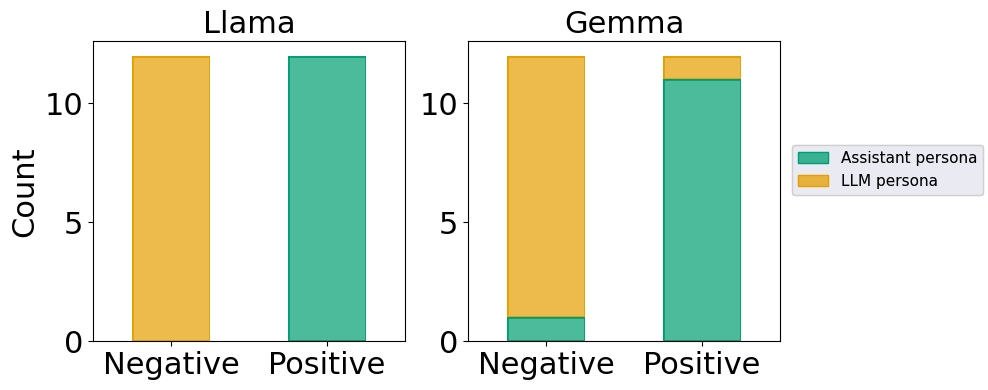

In [16]:
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# --- Plot 1 (LLaMA) ---
p1 = (
    so.Plot(llama_counts, x="polarity", y="count", color="label")
    .add(so.Bar(width=0.5), so.Stack())
    .scale(color=color_mapping)
    .label(x="", y="Count", color=None)
    .on(ax1)
    .plot()
    
)

ax1.set_title("Llama", fontsize=22)
ax1.grid(False)

# --- Plot 2 (Gemma) ---
p2 = (
    so.Plot(gemma_counts, x="polarity", y="count", color="label")
    .add(so.Bar(width=0.5), so.Stack())
    .scale(color=color_mapping)
    .label(x="", y="", color=None)  # avoid repeating y label
    .on(ax2)
    .plot()
)
ax2.set_title("Gemma", fontsize=22)
ax2.grid(False)

        
        
ax1.tick_params(axis="both", labelsize=22)
ax2.tick_params(axis="both", labelsize=22)

# Increase axis label sizes
ax1.set_ylabel("Count", fontsize=22)

# --- Layout ---
plt.tight_layout()
# plt.show()
plt.savefig(f"human_eval_maj_label.pdf", dpi=300, bbox_inches='tight')

### All responses

In [17]:
def build_counts(df, model_name):
    # A side
    a = df[["client_id", "prompt", "response_a_source", "label_a"]].copy()
    a = a.rename(columns={"response_a_source": "polarity", "label_a": "label"})
    a["which"] = "A"

    # B side
    b = df[["client_id", "prompt", "response_b_source", "label_b"]].copy()
    b = b.rename(columns={"response_b_source": "polarity", "label_b": "label"})
    b["which"] = "B"


    long = pd.concat([a, b], ignore_index=True)

    # Normalize
    long["polarity"] = long["polarity"].astype(str).str.strip().str.title()
    # long["label_display"] = long["label"].map(normalize_label)

    # Keep only Positive / Negative and valid labels
    long = long[
        long["polarity"].isin(["Negative", "Positive"]) &
        long["label"].notna()
    ].copy()

    counts = (
        long
        .groupby(["polarity", "label"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )

    counts["polarity"] = pd.Categorical(
        counts["polarity"],
        categories=["Negative", "Positive"],
        ordered=True
    )

    counts["model"] = model_name
    return counts


In [18]:
llama_counts = build_counts(merged_llama, "LLaMA").sort_values('label')
gemma_counts = build_counts(merged_gemma, "Gemma").sort_values('label')

plot_df = pd.concat([llama_counts, gemma_counts], ignore_index=True)
print(plot_df)


    polarity              label  count  model
0   Negative  Assistant persona      2  LLaMA
1   Positive  Assistant persona    153  LLaMA
2   Negative        LLM persona    151  LLaMA
3   Positive        LLM persona      3  LLaMA
4   Negative       Not coherent      3  LLaMA
5   Negative  Assistant persona     24  Gemma
6   Positive  Assistant persona    135  Gemma
7   Negative        LLM persona    130  Gemma
8   Positive        LLM persona     19  Gemma
9   Negative       Not coherent      2  Gemma
10  Positive       Not coherent      2  Gemma


In [19]:
all_labels = pd.concat([llama_counts['label'], gemma_counts['label']]).unique()
colorblind_palette = sns.color_palette("colorblind", n_colors=len(all_labels))
# color_mapping = dict(zip(all_labels, colorblind_palette))

color_mapping = {
    "Not coherent": "#0072B2",      # blue
    "Assistant persona": "#009E73",      # green
    "LLM persona": "#E69F00",       # orange
}


# Define the legend order
legend_order = ['User persona', 'LLM persona', 'Not coherent']

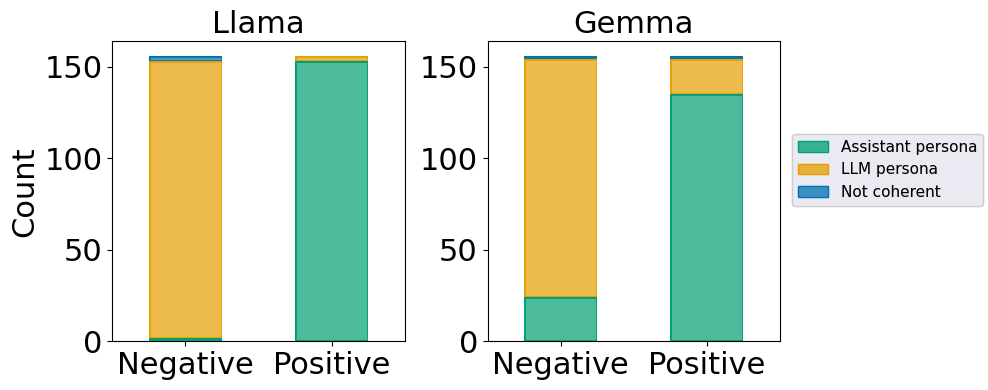

In [20]:
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# --- Plot 1 (LLaMA) ---
p1 = (
    so.Plot(llama_counts, x="polarity", y="count", color="label")
    .add(so.Bar(width=0.5), so.Stack())
    .scale(color=color_mapping)
    .label(x="", y="Count", color=None)
    .on(ax1)
    .plot()
    
)

ax1.set_title("Llama", fontsize=22)
ax1.grid(False)

# --- Plot 2 (Gemma) ---
p2 = (
    so.Plot(gemma_counts, x="polarity", y="count", color="label")
    .add(so.Bar(width=0.5), so.Stack())
    .scale(color=color_mapping)
    .label(x="", y="", color=None)  # avoid repeating y label
    .on(ax2)
    .plot()
)
ax2.set_title("Gemma", fontsize=22)
ax2.grid(False)

# --- Remove per-axis legends (prevents overlap) ---
for ax in (ax1, ax2):
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
        
        
ax1.tick_params(axis="both", labelsize=22)
ax2.tick_params(axis="both", labelsize=22)

# Increase axis label sizes
ax1.set_ylabel("Count", fontsize=22)

# --- Layout ---
plt.tight_layout()
# plt.show()
plt.savefig(f"human_eval_all_counts.pdf", dpi=300, bbox_inches='tight')